# Tech Challenge Fase 3 - Predição de atrasos de voos nos EUA (2015)

**Aluno:** Jonathan Ribeiro Cavalcante - RM369722

Neste notebook, o trabalho foi organizado em cinco etapas: leitura exploratória dos dados,
modelagem supervisionada para classificação e regressão, análise não supervisionada,
análises complementares e conclusão.


## Preparação do ambiente


In [16]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


---

# FASE 1: EDA (Exploração de Dados) + Limpeza

## 1.1 Carregamento dos Datasets

In [17]:
# Carregar datasets
flights = pd.read_csv('flights.csv', low_memory=False)
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')

print(f"FLIGHTS: {flights.shape[0]:,} voos x {flights.shape[1]} colunas")
print(f"AIRLINES: {airlines.shape[0]} companhias")
print(f"AIRPORTS: {airports.shape[0]} aeroportos")
print("\n" + "="*60)
print("COLUNAS DO DATASET FLIGHTS:")
print("="*60)
for i, col in enumerate(flights.columns, 1):
    print(f"{i:2d}. {col}")

FLIGHTS: 5,819,079 voos x 31 colunas
AIRLINES: 14 companhias
AIRPORTS: 322 aeroportos

COLUNAS DO DATASET FLIGHTS:
 1. YEAR
 2. MONTH
 3. DAY
 4. DAY_OF_WEEK
 5. AIRLINE
 6. FLIGHT_NUMBER
 7. TAIL_NUMBER
 8. ORIGIN_AIRPORT
 9. DESTINATION_AIRPORT
10. SCHEDULED_DEPARTURE
11. DEPARTURE_TIME
12. DEPARTURE_DELAY
13. TAXI_OUT
14. WHEELS_OFF
15. SCHEDULED_TIME
16. ELAPSED_TIME
17. AIR_TIME
18. DISTANCE
19. WHEELS_ON
20. TAXI_IN
21. SCHEDULED_ARRIVAL
22. ARRIVAL_TIME
23. ARRIVAL_DELAY
24. DIVERTED
25. CANCELLED
26. CANCELLATION_REASON
27. AIR_SYSTEM_DELAY
28. SECURITY_DELAY
29. AIRLINE_DELAY
30. LATE_AIRCRAFT_DELAY
31. WEATHER_DELAY


## 1.2 Estatísticas Descritivas Iniciais

In [57]:
# Estatísticas descritivas das colunas numéricas principais
numeric_cols = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'DEPARTURE_DELAY',
                'ARRIVAL_DELAY', 'DISTANCE', 'AIR_TIME', 'SCHEDULED_TIME']

print("Estatísticas Descritivas - Colunas Principais:")
print(flights[numeric_cols].describe())

print("\n" + "="*60)
print("DISTRIBUIÇÃO DE VOOS POR COMPANHIA AÉREA:")
print("="*60)
airline_counts = flights['AIRLINE'].value_counts().head(10)
print(airline_counts)

print("\n" + "="*60)
print("TOP 10 AEROPORTOS DE ORIGEM (mais voos):")
print("="*60)
origin_counts = flights['ORIGIN_AIRPORT'].value_counts().head(10)
print(origin_counts)

Estatísticas Descritivas - Colunas Principais:
              MONTH           DAY   DAY_OF_WEEK  DEPARTURE_DELAY  \
count  5.819079e+06  5.819079e+06  5.819079e+06     5.732926e+06   
mean   6.524085e+00  1.570459e+01  3.926941e+00     9.370158e+00   
std    3.405137e+00  8.783425e+00  1.988845e+00     3.708094e+01   
min    1.000000e+00  1.000000e+00  1.000000e+00    -8.200000e+01   
25%    4.000000e+00  8.000000e+00  2.000000e+00    -5.000000e+00   
50%    7.000000e+00  1.600000e+01  4.000000e+00    -2.000000e+00   
75%    9.000000e+00  2.300000e+01  6.000000e+00     7.000000e+00   
max    1.200000e+01  3.100000e+01  7.000000e+00     1.988000e+03   

       ARRIVAL_DELAY      DISTANCE      AIR_TIME  SCHEDULED_TIME  
count   5.714008e+06  5.819079e+06  5.714008e+06    5.819073e+06  
mean    4.407057e+00  8.223565e+02  1.135116e+02    1.416859e+02  
std     3.927130e+01  6.077843e+02  7.223082e+01    7.521058e+01  
min    -8.700000e+01  2.100000e+01  7.000000e+00    1.800000e+01  
25%  

## 1.3 Análise de Valores Ausentes

COLUNAS COM VALORES AUSENTES:
                     Missing  Percent
CANCELLATION_REASON  5729195    98.46
SECURITY_DELAY       4755640    81.72
AIR_SYSTEM_DELAY     4755640    81.72
LATE_AIRCRAFT_DELAY  4755640    81.72
WEATHER_DELAY        4755640    81.72
AIRLINE_DELAY        4755640    81.72
ARRIVAL_DELAY         105071     1.81
ELAPSED_TIME          105071     1.81
AIR_TIME              105071     1.81
TAXI_IN                92513     1.59
WHEELS_ON              92513     1.59
ARRIVAL_TIME           92513     1.59
TAXI_OUT               89047     1.53
WHEELS_OFF             89047     1.53
DEPARTURE_DELAY        86153     1.48
DEPARTURE_TIME         86153     1.48
TAIL_NUMBER            14721     0.25
SCHEDULED_TIME             6     0.00


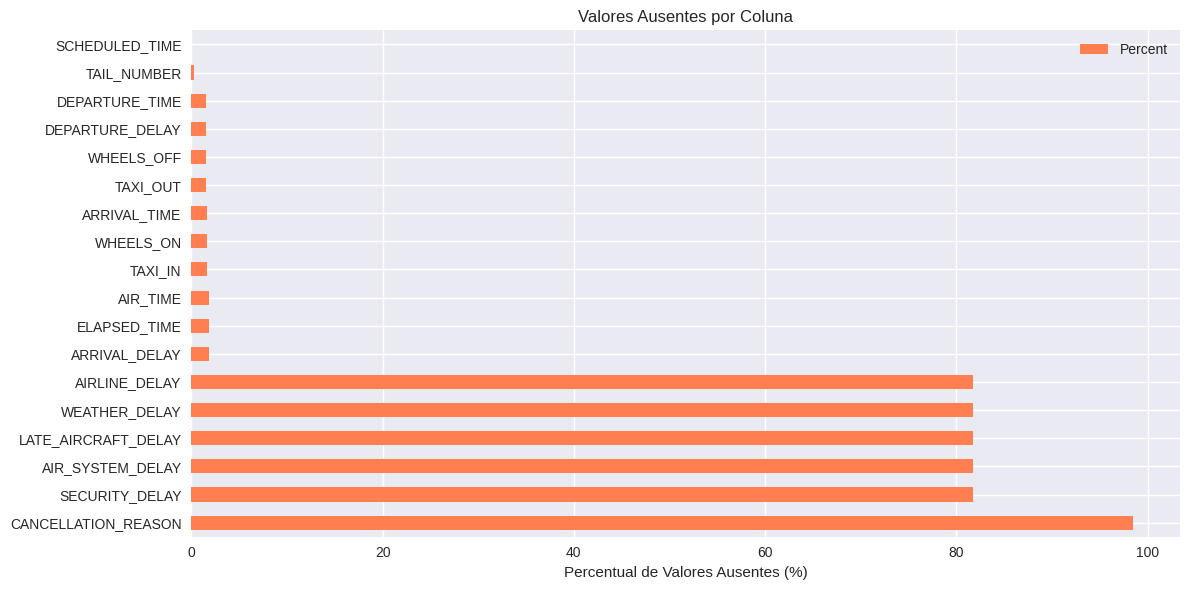

In [19]:
# Análise de missing values
missing = flights.isnull().sum()
missing_pct = (missing / len(flights) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False)

print("COLUNAS COM VALORES AUSENTES:")
print(missing_df)

# Visualização
fig, ax = plt.subplots(figsize=(12, 6))
missing_df.plot(kind='barh', y='Percent', ax=ax, color='coral')
ax.set_xlabel('Percentual de Valores Ausentes (%)')
ax.set_title('Valores Ausentes por Coluna')
plt.tight_layout()
plt.show()

## 1.4 Análise de Atrasos - Target Principal

**Pergunta guia:** Quais aeroportos são mais críticos? Quais características aumentam a chance de atraso?

In [21]:
    # Para analisar atraso de partida, considero apenas voos que realmente aconteceram.
    flights_valid = flights[flights['CANCELLED'] == 0].copy()
    flights_valid['IS_DELAYED'] = (flights_valid['DEPARTURE_DELAY'] > 15).astype(int)

    total_voos = len(flights_valid)
    voos_atrasados = flights_valid['IS_DELAYED'].sum()
    pct_atraso = voos_atrasados / total_voos * 100

    print("Análise de atrasos na partida (> 15 minutos)")
    print("=" * 50)
    print(f"Voos não cancelados analisados: {total_voos:,}")
    print(f"Voos com atraso: {voos_atrasados:,}")
    print(f"Percentual de atraso: {pct_atraso:.2f}%")
    print(f"Voos pontuais: {total_voos - voos_atrasados:,} ({100 - pct_atraso:.2f}%)")

    atrasos = flights_valid[flights_valid['DEPARTURE_DELAY'] > 0]['DEPARTURE_DELAY']
    print(f"\nEstatísticas dos atrasos positivos (em minutos):")
    print(f"Média: {atrasos.mean():.1f} min")
    print(f"Mediana: {atrasos.median():.1f} min")
    print(f"Máximo: {atrasos.max():.0f} min")
    print(f"90º percentil: {atrasos.quantile(0.90):.1f} min")
    print(f"95º percentil: {atrasos.quantile(0.95):.1f} min")
    print(f"99º percentil: {atrasos.quantile(0.99):.1f} min")


Análise de atrasos na partida (> 15 minutos)
Voos não cancelados analisados: 5,729,195
Voos com atraso: 1,016,536
Percentual de atraso: 17.74%
Voos pontuais: 4,712,659 (82.26%)

Estatísticas dos atrasos positivos (em minutos):
Média: 32.6 min
Mediana: 14.0 min
Máximo: 1988 min
90º percentil: 83.0 min
95º percentil: 126.0 min
99º percentil: 243.0 min


## 1.5 Visualizações exploratórias


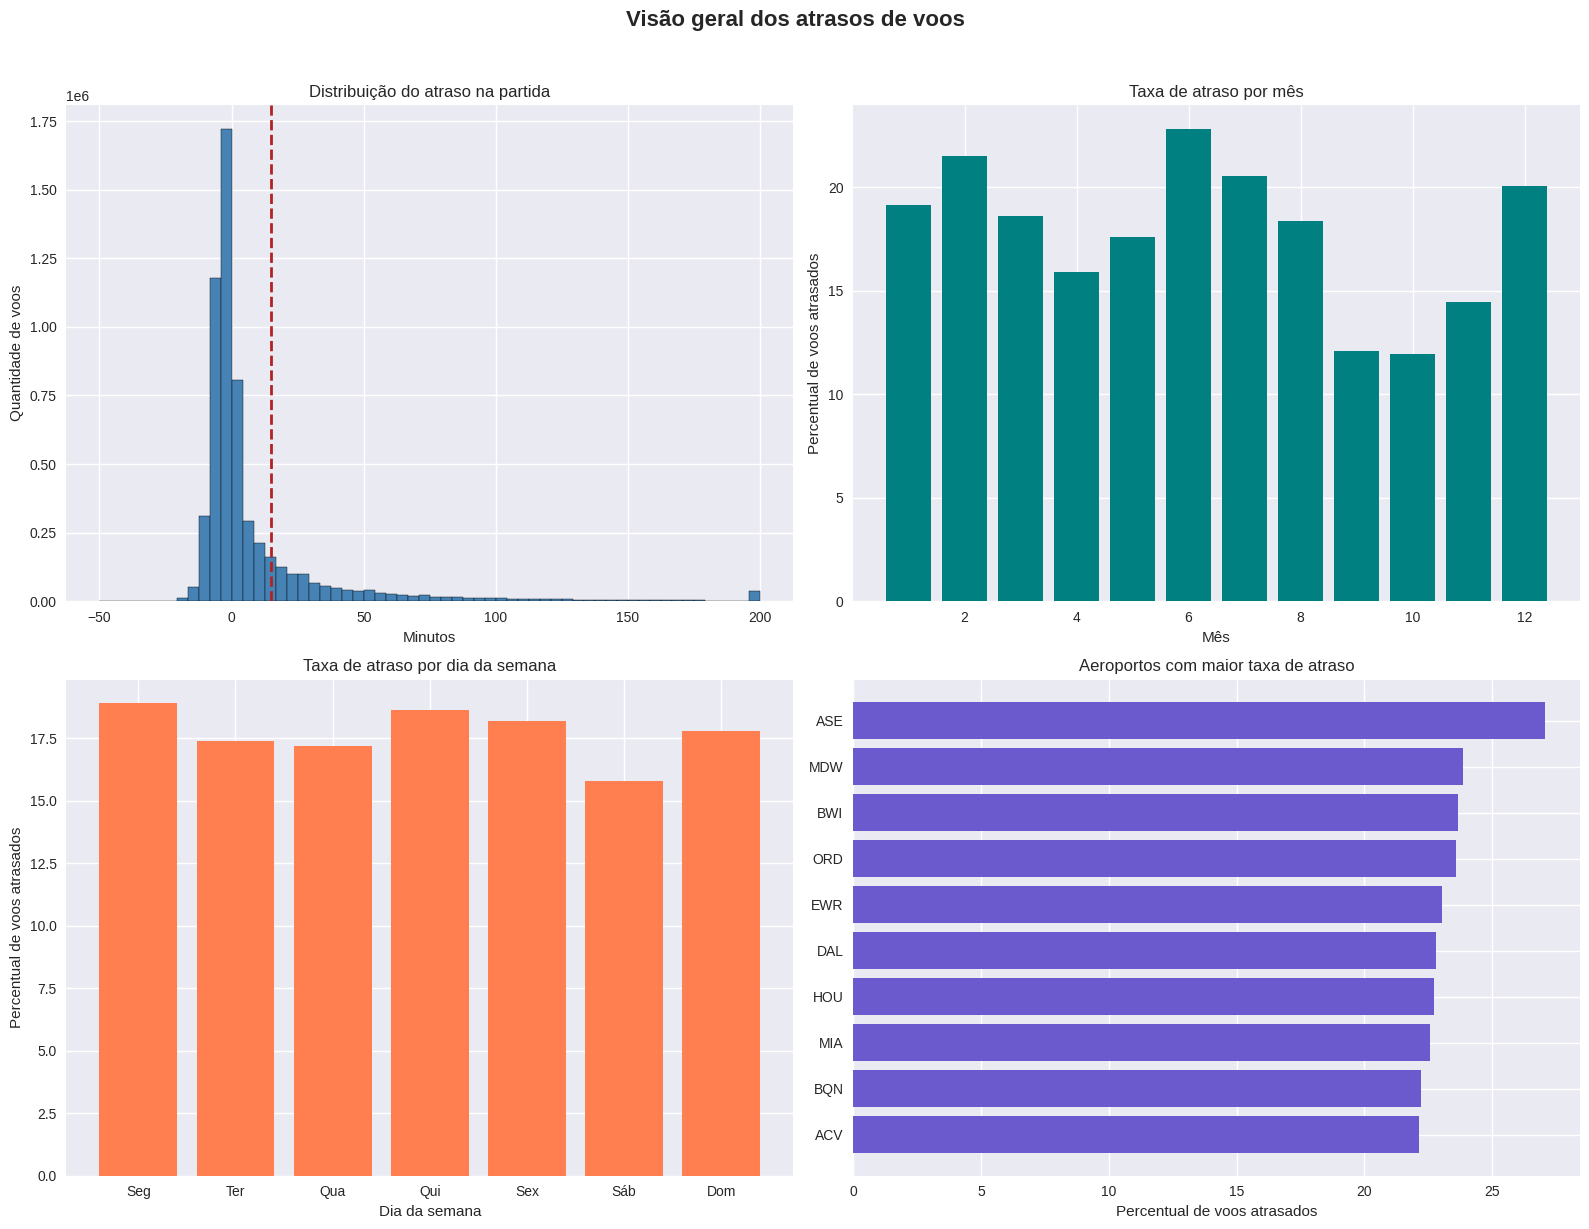

In [22]:
monthly_delay = flights_valid.groupby('MONTH')['IS_DELAYED'].mean() * 100
dow_delay = flights_valid.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean() * 100
dow_labels = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

top_delayed_airports = (
    flights_valid.groupby('ORIGIN_AIRPORT')
    .agg(total_voos=('IS_DELAYED', 'count'), pct_atraso=('IS_DELAYED', 'mean'))
    .reset_index()
)
top_delayed_airports = (
    top_delayed_airports[top_delayed_airports['total_voos'] >= 1000]
    .sort_values('pct_atraso', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(
    flights_valid['DEPARTURE_DELAY'].clip(-50, 200),
    bins=60,
    color='steelblue',
    edgecolor='black'
)
axes[0, 0].axvline(15, color='firebrick', linestyle='--', linewidth=2)
axes[0, 0].set_title('Distribuição do atraso na partida')
axes[0, 0].set_xlabel('Minutos')
axes[0, 0].set_ylabel('Quantidade de voos')

axes[0, 1].bar(monthly_delay.index, monthly_delay.values, color='teal')
axes[0, 1].set_title('Taxa de atraso por mês')
axes[0, 1].set_xlabel('Mês')
axes[0, 1].set_ylabel('Percentual de voos atrasados')

axes[1, 0].bar(range(1, 8), dow_delay.values, color='coral')
axes[1, 0].set_xticks(range(1, 8))
axes[1, 0].set_xticklabels(dow_labels)
axes[1, 0].set_title('Taxa de atraso por dia da semana')
axes[1, 0].set_xlabel('Dia da semana')
axes[1, 0].set_ylabel('Percentual de voos atrasados')

axes[1, 1].barh(
    top_delayed_airports['ORIGIN_AIRPORT'],
    top_delayed_airports['pct_atraso'] * 100,
    color='slateblue'
)
axes[1, 1].set_title('Aeroportos com maior taxa de atraso')
axes[1, 1].set_xlabel('Percentual de voos atrasados')
axes[1, 1].invert_yaxis()

plt.suptitle('Visão geral dos atrasos de voos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 1.6 Criação de variáveis derivadas


Criando variáveis derivadas...
Variáveis criadas:
  - SCHEDULED_DEPARTURE_HOUR
  - PERIOD_OF_DAY
  - SEASON
  - IS_WEEKEND
  - DISTANCE_CATEGORY


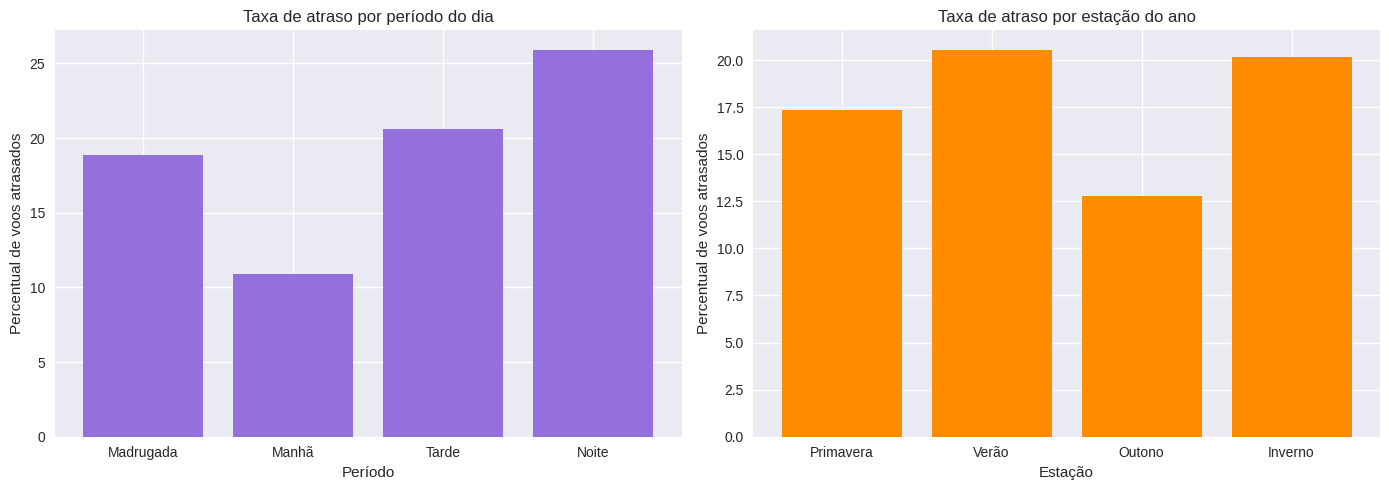

In [23]:
print("Criando variáveis derivadas...")

flights_valid['SCHEDULED_DEPARTURE_HOUR'] = (
    flights_valid['SCHEDULED_DEPARTURE'].fillna(0).astype(int) // 100
).clip(0, 23)

def get_period(hour):
    if 5 <= hour < 12:
        return 'Manhã'
    elif 12 <= hour < 18:
        return 'Tarde'
    elif 18 <= hour < 23:
        return 'Noite'
    else:
        return 'Madrugada'

def get_season(month):
    if month in [12, 1, 2]:
        return 'Inverno'
    elif month in [3, 4, 5]:
        return 'Primavera'
    elif month in [6, 7, 8]:
        return 'Verão'
    else:
        return 'Outono'

flights_valid['PERIOD_OF_DAY'] = flights_valid['SCHEDULED_DEPARTURE_HOUR'].apply(get_period)
flights_valid['SEASON'] = flights_valid['MONTH'].apply(get_season)
flights_valid['IS_WEEKEND'] = flights_valid['DAY_OF_WEEK'].isin([6, 7]).astype(int)

q1, q2, q3 = flights_valid['DISTANCE'].quantile([0.25, 0.50, 0.75])
flights_valid['DISTANCE_CATEGORY'] = pd.cut(
    flights_valid['DISTANCE'],
    bins=[-np.inf, q1, q2, q3, np.inf],
    labels=['Curta', 'Média', 'Longa', 'Muito longa'],
    include_lowest=True
)

print("Variáveis criadas:")
print("  - SCHEDULED_DEPARTURE_HOUR")
print("  - PERIOD_OF_DAY")
print("  - SEASON")
print("  - IS_WEEKEND")
print("  - DISTANCE_CATEGORY")

period_order = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
season_order = ['Primavera', 'Verão', 'Outono', 'Inverno']

period_delay = flights_valid.groupby('PERIOD_OF_DAY')['IS_DELAYED'].mean().reindex(period_order) * 100
season_delay = flights_valid.groupby('SEASON')['IS_DELAYED'].mean().reindex(season_order) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(period_delay.index, period_delay.values, color='mediumpurple')
axes[0].set_title('Taxa de atraso por período do dia')
axes[0].set_xlabel('Período')
axes[0].set_ylabel('Percentual de voos atrasados')

axes[1].bar(season_delay.index, season_delay.values, color='darkorange')
axes[1].set_title('Taxa de atraso por estação do ano')
axes[1].set_xlabel('Estação')
axes[1].set_ylabel('Percentual de voos atrasados')

plt.tight_layout()
plt.show()


## 1.7 Preparação dos dados para modelagem


In [26]:
    # Variáveis conhecidas antes da decolagem
    features_before_flight = [
        'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
        'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME',
        'DISTANCE', 'SCHEDULED_ARRIVAL',
        'SCHEDULED_DEPARTURE_HOUR', 'PERIOD_OF_DAY', 'SEASON',
        'IS_WEEKEND', 'DISTANCE_CATEGORY'
    ]

    # Para os modelos supervisionados, uso uma amostra balanceada.
    # Isso ajuda a comparar os algoritmos sem perder muito tempo de processamento.
    SAMPLE_SIZE = 200_000
    sample_per_class = SAMPLE_SIZE // 2

    delayed_sample = flights_valid[flights_valid['IS_DELAYED'] == 1].sample(
        n=min(sample_per_class, (flights_valid['IS_DELAYED'] == 1).sum()),
        random_state=42
    )
    on_time_sample = flights_valid[flights_valid['IS_DELAYED'] == 0].sample(
        n=min(sample_per_class, (flights_valid['IS_DELAYED'] == 0).sum()),
        random_state=42
    )

    flights_sample = (
        pd.concat([delayed_sample, on_time_sample], axis=0)
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

    print(f"Voos não cancelados disponíveis: {len(flights_valid):,}")
    print(f"Amostra usada na modelagem: {len(flights_sample):,}")
    print("Observação: a amostra foi balanceada de propósito.")
    print(f"  - Atrasados: {flights_sample['IS_DELAYED'].sum():,}")
    print(f"  - Pontuais: {(flights_sample['IS_DELAYED'] == 0).sum():,}")

    flights_sample.to_csv('flights_sample.csv', index=False)
    print("\nAmostra salva em 'flights_sample.csv'.")


Voos não cancelados disponíveis: 5,729,195
Amostra usada na modelagem: 200,000
Observação: a amostra foi balanceada de propósito.
  - Atrasados: 100,000
  - Pontuais: 100,000

Amostra salva em 'flights_sample.csv'.


---

# FASE 2: Modelagem Supervisionada - CLASSIFICAÇÃO

**Objetivo:** Prever se um voo vai atrasar (> 15 min) ou não

**Modelos:** Random Forest, Logistic Regression, XGBoost (opcional)

In [27]:
# Preparar base para classificação e regressão
X = flights_sample[features_before_flight].copy()
y_class = flights_sample['IS_DELAYED'].copy()
y_reg = flights_sample['DEPARTURE_DELAY'].copy()

cat_cols = [
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'PERIOD_OF_DAY', 'SEASON', 'DISTANCE_CATEGORY'
]

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

feature_cols = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE',
    'SCHEDULED_DEPARTURE_HOUR', 'IS_WEEKEND'
]

X_model = X[feature_cols].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_class, test_size=0.2, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados preparados para classificação:")
print(f"  - Quantidade de variáveis usadas: {X_model.shape[1]}")
print(f"  - Treino: {X_train.shape[0]:,} amostras")
print(f"  - Teste: {X_test.shape[0]:,} amostras")
print(f"  - Atrasados no treino: {y_train.mean() * 100:.1f}%")
print(f"  - Atrasados no teste: {y_test.mean() * 100:.1f}%")


Dados preparados para classificação:
  - Quantidade de variáveis usadas: 9
  - Treino: 160,000 amostras
  - Teste: 40,000 amostras
  - Atrasados no treino: 50.0%
  - Atrasados no teste: 50.0%


## 2.1 Modelo 1: regressão logística


In [30]:
    print("Treinando regressão logística...")

    lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    lr.fit(X_train_scaled, y_train)

    y_pred_lr = lr.predict(X_test_scaled)
    y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
    auc_lr = roc_auc_score(y_test, y_proba_lr)
    precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(
        y_test, y_pred_lr, average='binary'
    )

    print("\nResultados da regressão logística:")
    print(f"  - ROC-AUC: {auc_lr:.4f}")
    print(f"  - Precisão: {precision_lr:.4f}")
    print(f"  - Recall: {recall_lr:.4f}")
    print(f"  - F1: {f1_lr:.4f}")
    print(f"\n{classification_report(y_test, y_pred_lr, target_names=['Pontual', 'Atrasado'])}")


Treinando regressão logística...

Resultados da regressão logística:
  - ROC-AUC: 0.6348
  - Precisão: 0.5993
  - Recall: 0.6120
  - F1: 0.6056

              precision    recall  f1-score   support

     Pontual       0.60      0.59      0.60     20000
    Atrasado       0.60      0.61      0.61     20000

    accuracy                           0.60     40000
   macro avg       0.60      0.60      0.60     40000
weighted avg       0.60      0.60      0.60     40000



## 2.2 Modelo 2: random forest


In [32]:
    print("Treinando random forest...")

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=50,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:, 1]
    auc_rf = roc_auc_score(y_test, y_proba_rf)
    precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
        y_test, y_pred_rf, average='binary'
    )

    print("\nResultados do random forest:")
    print(f"  - ROC-AUC: {auc_rf:.4f}")
    print(f"  - Precisão: {precision_rf:.4f}")
    print(f"  - Recall: {recall_rf:.4f}")
    print(f"  - F1: {f1_rf:.4f}")
    print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Pontual', 'Atrasado'])}")


Treinando random forest...

Resultados do random forest:
  - ROC-AUC: 0.7015
  - Precisão: 0.6405
  - Recall: 0.6711
  - F1: 0.6554

              precision    recall  f1-score   support

     Pontual       0.65      0.62      0.64     20000
    Atrasado       0.64      0.67      0.66     20000

    accuracy                           0.65     40000
   macro avg       0.65      0.65      0.65     40000
weighted avg       0.65      0.65      0.65     40000



## 2.3 Variáveis mais relevantes no modelo


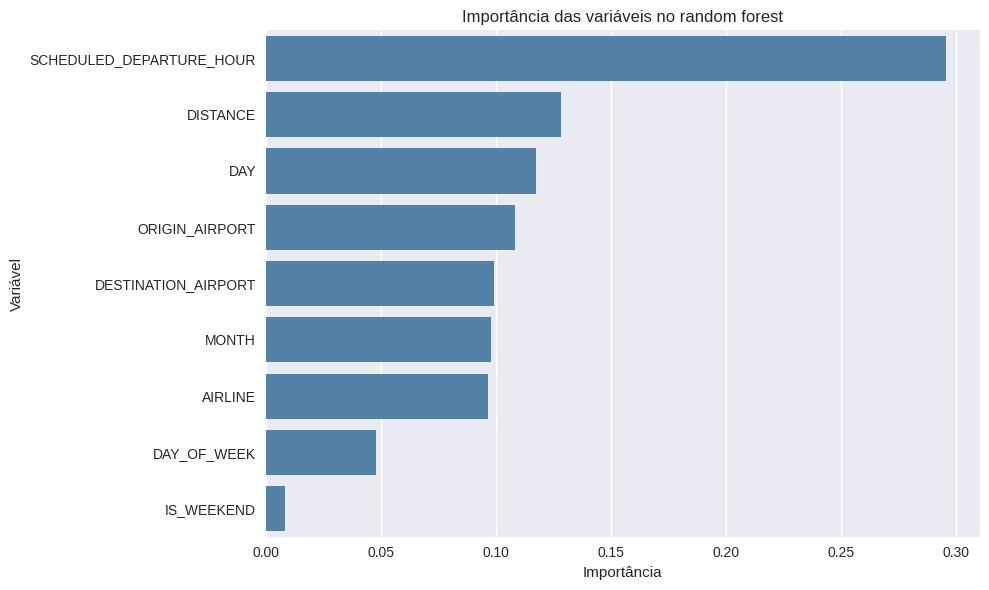

Variáveis mais importantes no random forest:
                Variável  Importância
SCHEDULED_DEPARTURE_HOUR       0.2955
                DISTANCE       0.1283
                     DAY       0.1176
          ORIGIN_AIRPORT       0.1084
     DESTINATION_AIRPORT       0.0991
                   MONTH       0.0978
                 AIRLINE       0.0967
             DAY_OF_WEEK       0.0481
              IS_WEEKEND       0.0084


In [33]:
importance_df = pd.DataFrame({
    'Variável': feature_cols,
    'Importância': rf.feature_importances_
}).sort_values('Importância', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x='Importância',
    y='Variável',
    color='steelblue',
    ax=ax
)
ax.set_title('Importância das variáveis no random forest')
ax.set_xlabel('Importância')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()

print("Variáveis mais importantes no random forest:")
print(importance_df.head(10).round(4).to_string(index=False))


## 2.4 Comparação dos modelos de classificação


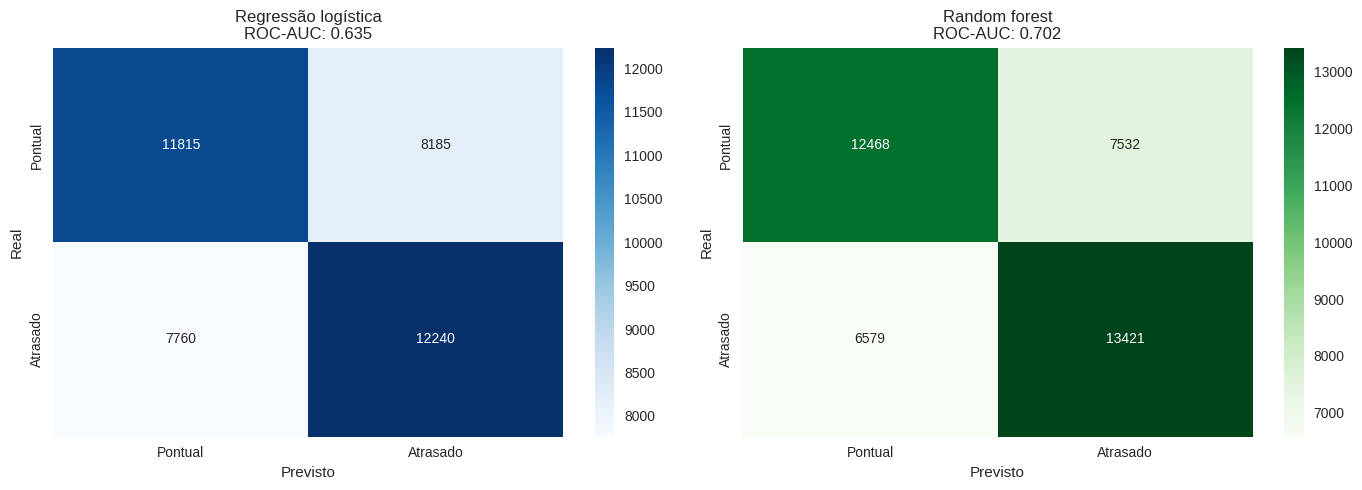

Comparação consolidada dos modelos de classificação:
             Modelo  ROC-AUC  Precisão  Recall     F1
Regressão logística   0.6348    0.5993   0.612 0.6056
      Random forest   0.7015    0.6405   0.671 0.6554


In [35]:
    cm_lr = confusion_matrix(y_test, y_pred_lr)
    cm_rf = confusion_matrix(y_test, y_pred_rf)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm_lr,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[0],
        xticklabels=['Pontual', 'Atrasado'],
        yticklabels=['Pontual', 'Atrasado']
    )
    axes[0].set_title(f'Regressão logística\nROC-AUC: {auc_lr:.3f}')
    axes[0].set_xlabel('Previsto')
    axes[0].set_ylabel('Real')

    sns.heatmap(
        cm_rf,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=axes[1],
        xticklabels=['Pontual', 'Atrasado'],
        yticklabels=['Pontual', 'Atrasado']
    )
    axes[1].set_title(f'Random forest\nROC-AUC: {auc_rf:.3f}')
    axes[1].set_xlabel('Previsto')
    axes[1].set_ylabel('Real')

    plt.tight_layout()
    plt.show()

    classification_results = pd.DataFrame({
        'Modelo': ['Regressão logística', 'Random forest'],
        'ROC-AUC': [auc_lr, auc_rf],
        'Precisão': [precision_lr, precision_rf],
        'Recall': [recall_lr, recall_rf],
        'F1': [f1_lr, f1_rf],
    })

    print("Comparação consolidada dos modelos de classificação:")
    print(classification_results.round(4).to_string(index=False))


---

# FASE 3: Modelagem Supervisionada - REGRESSÃO

**Objetivo:** Prever quantos minutos de atraso um voo terá na partida

**Modelos:** Random Forest Regressor, Ridge Regression

In [37]:
    y_train_reg = flights_sample.loc[X_train.index, 'DEPARTURE_DELAY']
    y_test_reg = flights_sample.loc[X_test.index, 'DEPARTURE_DELAY']

    print("Treinando regressão ridge...")
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train_reg)
    y_pred_ridge = ridge.predict(X_test_scaled)

    rmse_ridge = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))
    mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
    r2_ridge = r2_score(y_test_reg, y_pred_ridge)

    print("\nResultados da regressão ridge:")
    print(f"  - RMSE: {rmse_ridge:.2f} min")
    print(f"  - MAE: {mae_ridge:.2f} min")
    print(f"  - R²: {r2_ridge:.4f}")

    print("\nTreinando random forest regressor...")
    rf_reg = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=50,
        random_state=42,
        n_jobs=-1
    )
    rf_reg.fit(X_train, y_train_reg)
    y_pred_rf_reg = rf_reg.predict(X_test)

    rmse_rf_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
    mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)
    r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)

    print("\nResultados do random forest regressor:")
    print(f"  - RMSE: {rmse_rf_reg:.2f} min")
    print(f"  - MAE: {mae_rf_reg:.2f} min")
    print(f"  - R²: {r2_rf_reg:.4f}")

    regression_results = pd.DataFrame({
        'Modelo': ['Ridge', 'Random forest regressor'],
        'RMSE': [rmse_ridge, rmse_rf_reg],
        'MAE': [mae_ridge, mae_rf_reg],
        'R²': [r2_ridge, r2_rf_reg],
    })

    print("\nComparação dos modelos de regressão:")
    print(regression_results.round(4).to_string(index=False))


Treinando regressão ridge...

Resultados da regressão ridge:
  - RMSE: 55.96 min
  - MAE: 33.82 min
  - R²: 0.0144

Treinando random forest regressor...

Resultados do random forest regressor:
  - RMSE: 54.48 min
  - MAE: 32.70 min
  - R²: 0.0659

Comparação dos modelos de regressão:
                 Modelo    RMSE     MAE     R²
                  Ridge 55.9635 33.8172 0.0144
Random forest regressor 54.4825 32.7011 0.0659


## 3.1 Análise de resíduos


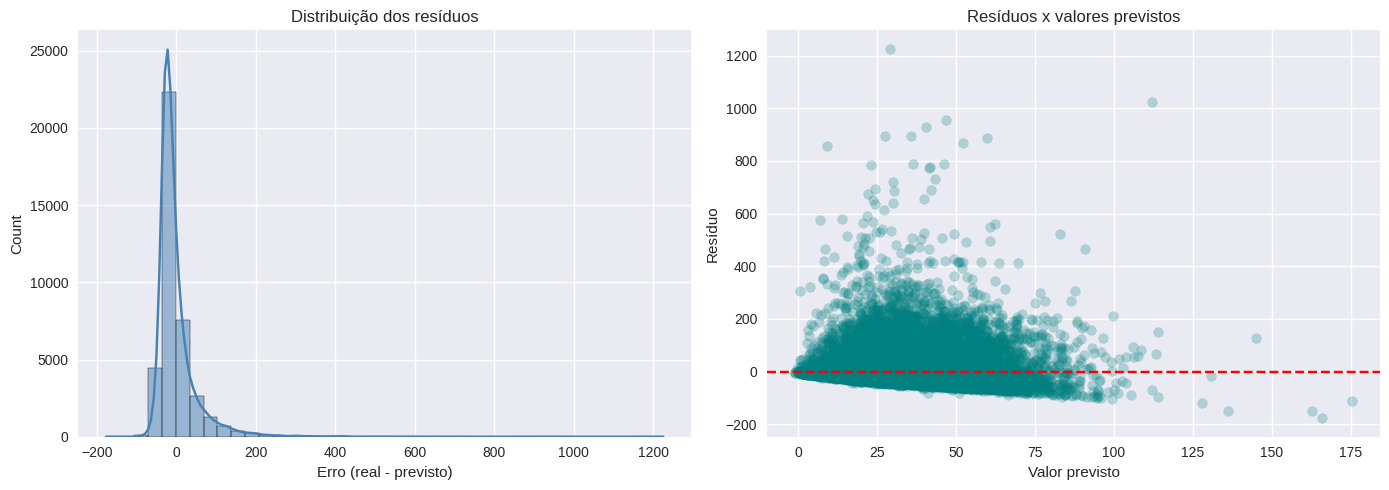

Resumo dos resíduos do random forest regressor:
count    40000.00
mean        -0.48
std         54.48
min       -177.04
25%        -28.31
50%        -14.91
75%          8.25
max       1225.78


In [38]:
residuals = y_test_reg - y_pred_rf_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribuição dos resíduos')
axes[0].set_xlabel('Erro (real - previsto)')

axes[1].scatter(y_pred_rf_reg, residuals, alpha=0.25, color='teal')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Resíduos x valores previstos')
axes[1].set_xlabel('Valor previsto')
axes[1].set_ylabel('Resíduo')

plt.tight_layout()
plt.show()

print("Resumo dos resíduos do random forest regressor:")
print(pd.Series(residuals).describe().round(2).to_string())


---

# FASE 4: Modelagem NÃO SUPERVISIONADA

**Pergunta guia:** É possível agrupar aeroportos com perfis semelhantes?

In [42]:
    airport_profile = flights_valid.groupby('ORIGIN_AIRPORT').agg(
        total_voos=('DEPARTURE_DELAY', 'count'),
        atraso_medio=('DEPARTURE_DELAY', 'mean'),
        desvio_atraso=('DEPARTURE_DELAY', 'std'),
        pct_atraso=('IS_DELAYED', 'mean'),
        distancia_media=('DISTANCE', 'mean'),
        tempo_programado_medio=('SCHEDULED_TIME', 'mean')
    ).reset_index()

    airport_profile = airport_profile[airport_profile['total_voos'] >= 500]
    airport_profile = airport_profile.fillna(0)

    print(f"Perfis de {len(airport_profile)} aeroportos criados")
    print("\nAmostra dos perfis:")
    print(airport_profile.head().to_string(index=False))


Perfis de 403 aeroportos criados

Amostra dos perfis:
ORIGIN_AIRPORT  total_voos  atraso_medio  desvio_atraso  pct_atraso  distancia_media  tempo_programado_medio
         10140        1809      5.962963      26.791234    0.134328       730.096739              122.557767
         10257         733      1.635744      19.375628    0.077763       689.604366              135.840382
         10299        1228      1.134365      26.065444    0.074919      1328.701954              186.070847
         10397       32557      4.228952      21.272916    0.107596       639.208711              121.731640
         10423        3879      7.871101      40.044320    0.127352       801.943800              136.727249


## 4.1 Clusterização com k-means


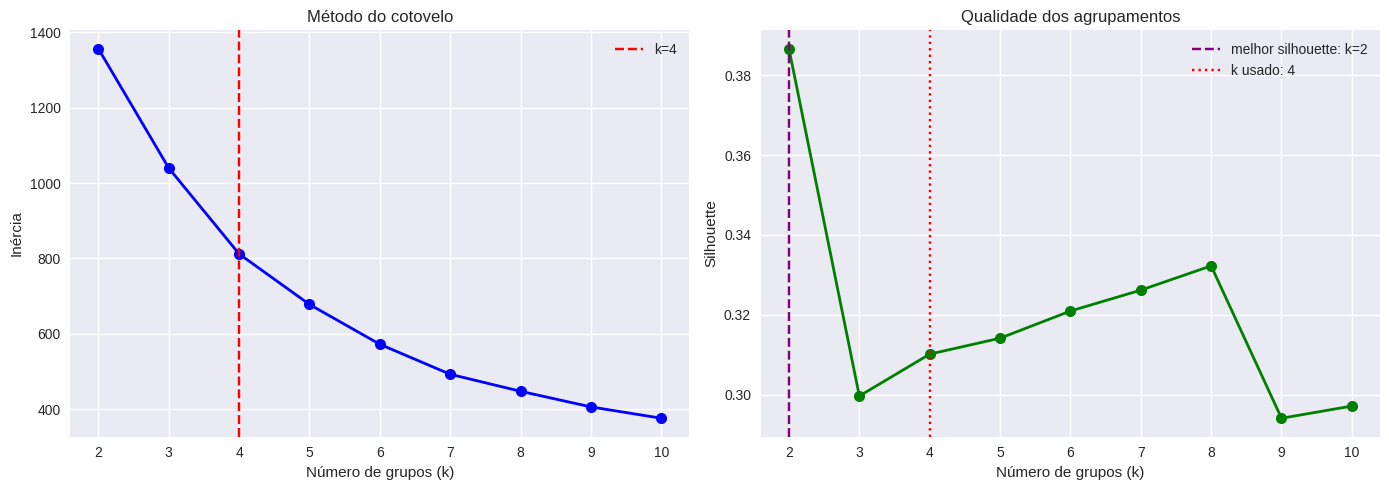

Distribuição dos aeroportos por cluster:
cluster
0    164
1    118
2     87
3     34
Name: count, dtype: int64

Melhor silhouette no intervalo testado: k=2 (0.3867)
k adotado na leitura final: 4 (0.3101)
Optei por manter k=4 porque a segmentação ficou mais interpretável para o trabalho.


In [43]:
    cluster_features = [
        'atraso_medio', 'pct_atraso', 'distancia_media',
        'tempo_programado_medio', 'total_voos'
    ]
    X_cluster = airport_profile[cluster_features].copy()

    scaler_cluster = StandardScaler()
    X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

    inertias = []
    silhouette_scores = []
    K_range = range(2, 11)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_cluster_scaled)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

    best_k = list(K_range)[int(np.argmax(silhouette_scores))]
    chosen_k = 4

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].axvline(x=chosen_k, color='red', linestyle='--', label=f'k={chosen_k}')
    axes[0].set_xlabel('Número de grupos (k)')
    axes[0].set_ylabel('Inércia')
    axes[0].set_title('Método do cotovelo')
    axes[0].legend()

    axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    axes[1].axvline(x=best_k, color='purple', linestyle='--', label=f'melhor silhouette: k={best_k}')
    axes[1].axvline(x=chosen_k, color='red', linestyle=':', label=f'k usado: {chosen_k}')
    axes[1].set_xlabel('Número de grupos (k)')
    axes[1].set_ylabel('Silhouette')
    axes[1].set_title('Qualidade dos agrupamentos')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
    airport_profile['cluster'] = kmeans.fit_predict(X_cluster_scaled)

    print("Distribuição dos aeroportos por cluster:")
    print(airport_profile['cluster'].value_counts().sort_index())
    print(f"\nMelhor silhouette no intervalo testado: k={best_k} ({max(silhouette_scores):.4f})")
    print(f"k adotado na leitura final: {chosen_k} ({silhouette_scores[chosen_k - 2]:.4f})")
    print("Optei por manter k=4 porque a segmentação ficou mais interpretável para o trabalho.")


## 4.2 Interpretação dos grupos de aeroportos


In [47]:
    cluster_summary = airport_profile.groupby('cluster')[cluster_features].mean()

    print("Perfil médio de cada cluster:")
    print("=" * 70)
    print(cluster_summary.round(2).to_string())

    for cluster_id, row in cluster_summary.round(2).iterrows():
        print(f"\nLeitura do cluster {cluster_id}:")
        print(
            f"  - atraso médio: {row['atraso_medio']:.2f} min | "
            f"taxa de atraso: {row['pct_atraso'] * 100:.1f}% | "
            f"volume médio: {row['total_voos']:.0f} voos"
        )


Perfil médio de cada cluster:
         atraso_medio  pct_atraso  distancia_media  tempo_programado_medio  total_voos
cluster                                                                               
0                8.61        0.16           472.41                   99.88     7394.24
1                3.31        0.11           361.90                   83.02     1465.30
2                4.54        0.12           889.27                  147.60     9136.90
3               11.08        0.20           973.35                  162.15   103248.26

Leitura do cluster 0:
  - atraso médio: 8.61 min | taxa de atraso: 16.0% | volume médio: 7394 voos

Leitura do cluster 1:
  - atraso médio: 3.31 min | taxa de atraso: 11.0% | volume médio: 1465 voos

Leitura do cluster 2:
  - atraso médio: 4.54 min | taxa de atraso: 12.0% | volume médio: 9137 voos

Leitura do cluster 3:
  - atraso médio: 11.08 min | taxa de atraso: 20.0% | volume médio: 103248 voos


## 4.3 Análise de componentes principais (PCA)


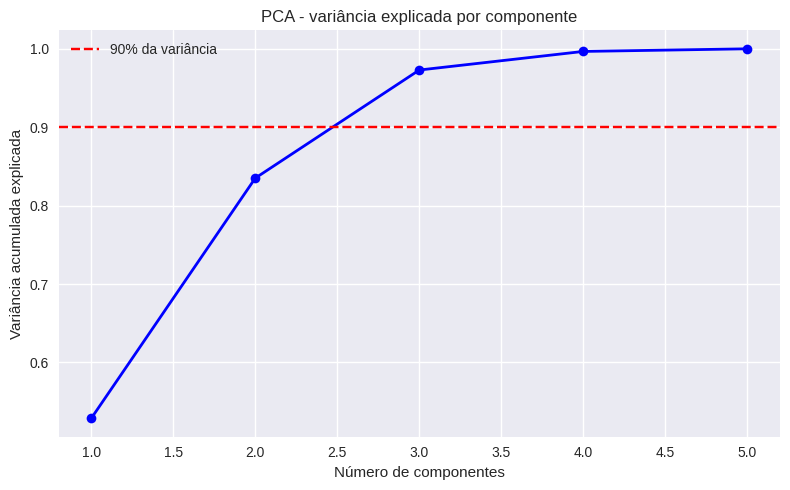

Variância explicada:
  PC1: 52.9%
  PC2: 30.6%
  PC3: 13.8%
  PC4: 2.4%
  PC5: 0.3%

Total nos 2 primeiros componentes: 83.5%
  Total nos 3 primeiros componentes: 97.3%


In [49]:
  pca_full = PCA()
  pca_full.fit(X_cluster_scaled)

  fig, ax = plt.subplots(figsize=(8, 5))
  ax.plot(
      range(1, len(pca_full.explained_variance_ratio_) + 1),
      np.cumsum(pca_full.explained_variance_ratio_),
      'bo-',
      linewidth=2
  )
  ax.axhline(y=0.9, color='red', linestyle='--', label='90% da variância')
  ax.set_xlabel('Número de componentes')
  ax.set_ylabel('Variância acumulada explicada')
  ax.set_title('PCA - variância explicada por componente')
  ax.legend()
  plt.tight_layout()
  plt.show()

  print("Variância explicada:")
  for i, var in enumerate(pca_full.explained_variance_ratio_, 1):
      print(f"  PC{i}: {var * 100:.1f}%")
  print(f"\nTotal nos 2 primeiros componentes: {np.sum(pca_full.explained_variance_ratio_[:2]) * 100:.1f}%")
  print(f"  Total nos 3 primeiros componentes: {np.sum(pca_full.explained_variance_ratio_[:3]) * 100:.1f}%")


## 4.4 Detecção de anomalias


In [52]:
    print("Detectando anomalias nos voos...")

    delayed_pool = flights_valid[flights_valid['DEPARTURE_DELAY'] > 0].copy()
    delayed_flights = delayed_pool.sample(n=min(150_000, len(delayed_pool)), random_state=42)

    anomaly_features = ['DEPARTURE_DELAY', 'DISTANCE', 'SCHEDULED_TIME', 'AIR_TIME']
    X_anomaly = delayed_flights[anomaly_features].fillna(0)

    iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
    delayed_flights['anomaly'] = iso_forest.fit_predict(X_anomaly)

    anomalies = delayed_flights[delayed_flights['anomaly'] == -1]
    normal = delayed_flights[delayed_flights['anomaly'] == 1]

    print("Detecção concluída:")
    print(f"  - Voos normais: {len(normal):,}")
    print(f"  - Anomalias detectadas: {len(anomalies):,} ({len(anomalies) / len(delayed_flights) * 100:.2f}%)")

    print("\nComparação entre voos normais e anomalias:")
    print(f"  {'':20} {'Normal':>12} {'Anomalia':>12}")
    print(f"  {'-' * 46}")
    for feat in anomaly_features:
        print(f"  {feat:20} {normal[feat].mean():>12.1f} {anomalies[feat].mean():>12.1f}")

    top_anomalies = anomalies.nlargest(10, 'DEPARTURE_DELAY')
    print("\nExemplos de anomalias com atrasos mais extremos:")
    print(
        top_anomalies[
            ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DEPARTURE_DELAY', 'DISTANCE']
        ].to_string(index=False)
    )


Detectando anomalias nos voos...
Detecção concluída:
  - Voos normais: 147,000
  - Anomalias detectadas: 3,000 (2.00%)

Comparação entre voos normais e anomalias:
                             Normal     Anomalia
  ----------------------------------------------
  DEPARTURE_DELAY              30.0        154.6
  DISTANCE                    849.5       2312.8
  SCHEDULED_TIME              144.8        333.3
  AIR_TIME                    116.1        298.1

Exemplos de anomalias com atrasos mais extremos:
AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  DEPARTURE_DELAY  DISTANCE
     AA            HNL                 LAX           1589.0      2556
     AA            MEM                 DFW           1380.0       432
     AA            OGG                 DFW           1313.0      3711
     AA            SJC                 DFW           1189.0      1438
     AA            HNL                 LAX           1142.0      2556
     DL            MCI                 SLC           1108.0       920
   

# Análises complementares


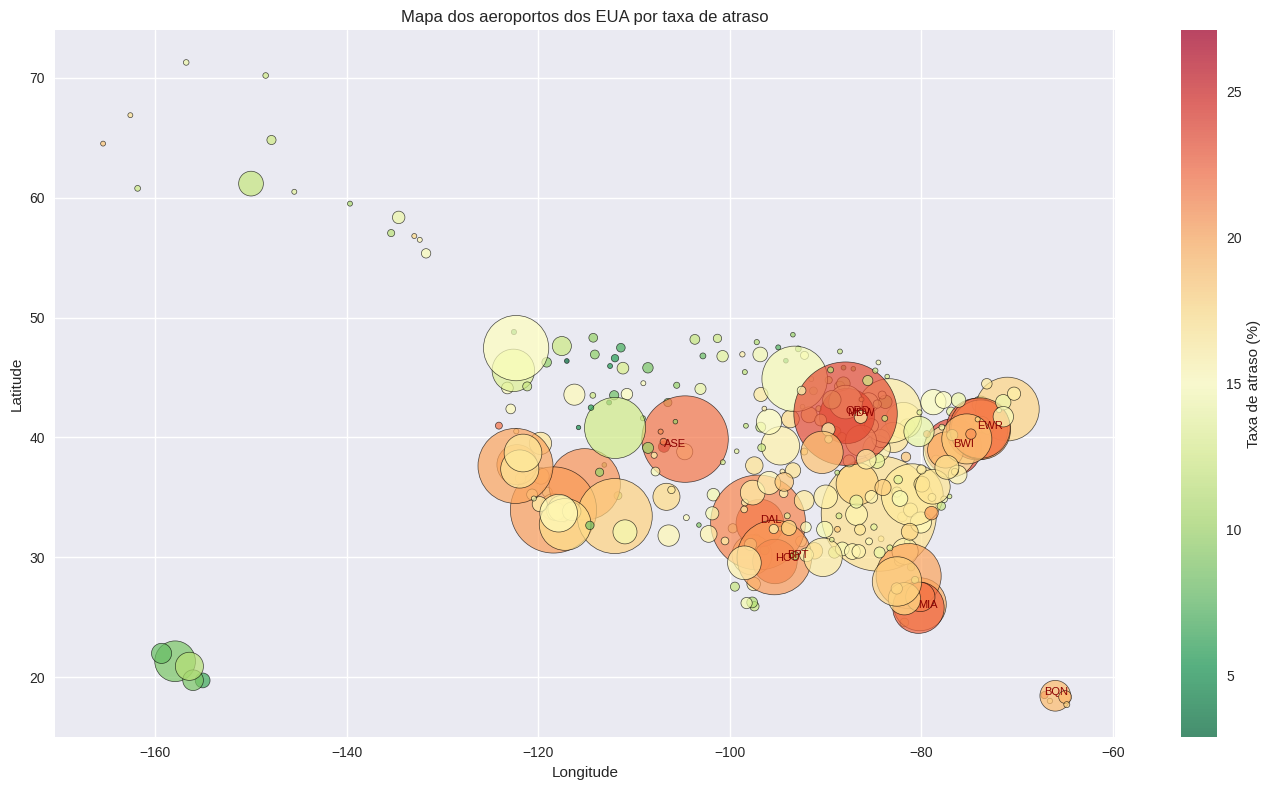

Mapa geográfico gerado.


In [51]:
airport_map = airport_profile.merge(
    airports, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left'
)

airport_map = airport_map.dropna(subset=['LATITUDE', 'LONGITUDE'])

fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(
    airport_map['LONGITUDE'],
    airport_map['LATITUDE'],
    c=airport_map['pct_atraso'] * 100,
    s=airport_map['total_voos'] / 50,
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mapa dos aeroportos dos EUA por taxa de atraso')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Taxa de atraso (%)')

worst_airports = airport_map.nlargest(10, 'pct_atraso')
for _, row in worst_airports.iterrows():
    ax.annotate(
        row['ORIGIN_AIRPORT'],
        (row['LONGITUDE'], row['LATITUDE']),
        fontsize=8,
        color='darkred'
    )

plt.tight_layout()
plt.show()

print("Mapa geográfico gerado.")


## Análise por companhia aérea e estado


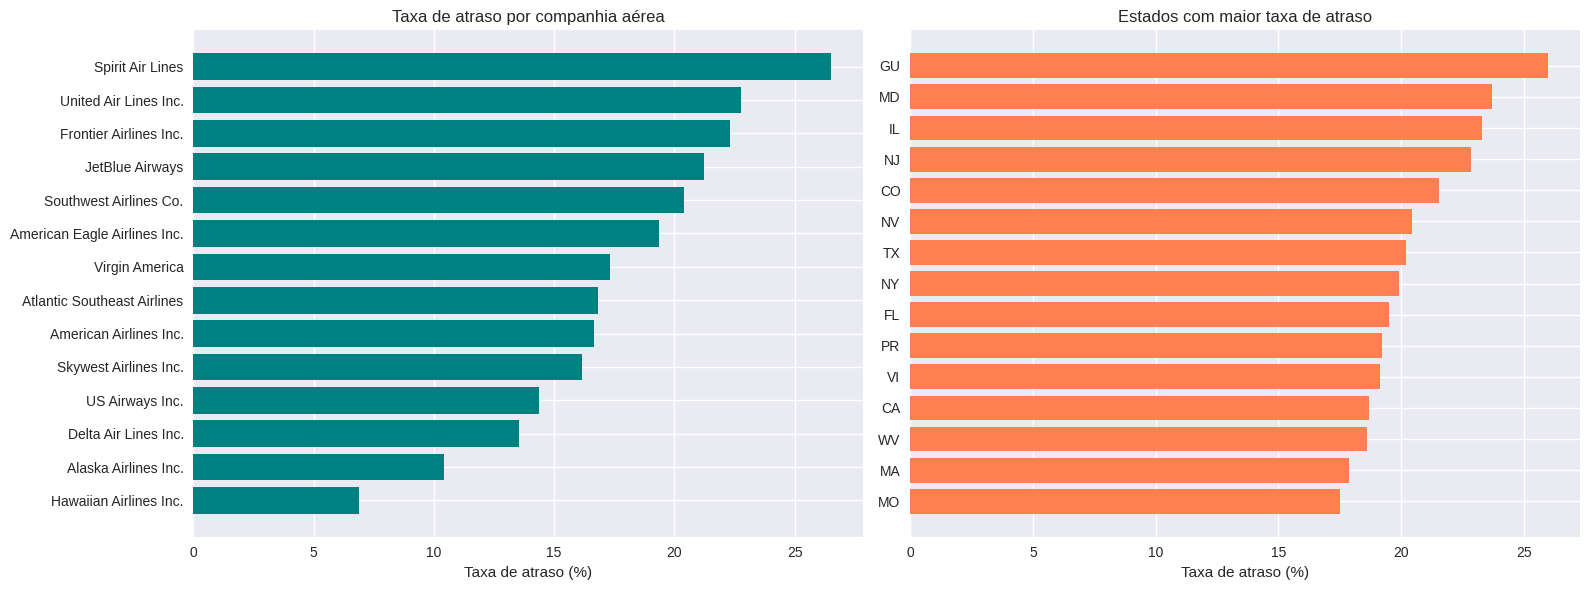

Companhias com maior e menor taxa de atraso:
                   AIRLINE_y  total_voos  pct_atraso
            Spirit Air Lines      115375       0.265
       United Air Lines Inc.      509150       0.228
      Frontier Airlines Inc.       90248       0.223
             JetBlue Airways      262772       0.212
      Southwest Airlines Co.     1245812       0.204
American Eagle Airlines Inc.      279607       0.194
              Virgin America       61369       0.173
 Atlantic Southeast Airlines      556746       0.168
      American Airlines Inc.      715065       0.167
       Skywest Airlines Inc.      578393       0.161
             US Airways Inc.      194648       0.144
        Delta Air Lines Inc.      872057       0.135
        Alaska Airlines Inc.      171852       0.104
      Hawaiian Airlines Inc.       76101       0.069


In [53]:
airline_delay = flights_valid.groupby('AIRLINE').agg(
    total_voos=('IS_DELAYED', 'count'),
    atraso_medio=('DEPARTURE_DELAY', 'mean'),
    pct_atraso=('IS_DELAYED', 'mean')
).reset_index()

airline_delay = airline_delay.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
airline_delay = airline_delay.sort_values('pct_atraso', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(airline_delay['AIRLINE_y'], airline_delay['pct_atraso'] * 100, color='teal')
axes[0].set_xlabel('Taxa de atraso (%)')
axes[0].set_title('Taxa de atraso por companhia aérea')
axes[0].invert_yaxis()

flights_with_state = flights_valid.merge(
    airports[['IATA_CODE', 'STATE']], left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left'
)
state_delay = flights_with_state.groupby('STATE').agg(
    total_voos=('IS_DELAYED', 'count'),
    pct_atraso=('IS_DELAYED', 'mean')
).reset_index()
state_delay = state_delay[state_delay['total_voos'] >= 100]
state_delay = state_delay.sort_values('pct_atraso', ascending=False).head(15)

axes[1].barh(state_delay['STATE'], state_delay['pct_atraso'] * 100, color='coral')
axes[1].set_xlabel('Taxa de atraso (%)')
axes[1].set_title('Estados com maior taxa de atraso')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Companhias com maior e menor taxa de atraso:")
print(airline_delay[['AIRLINE_y', 'total_voos', 'pct_atraso']].round(3).to_string(index=False))


# Etapa 5 - fechamento do trabalho


In [56]:
    print("=" * 70)
    print("Síntese dos resultados")
    print("=" * 70)

    print("\nModelos de classificação (voo atrasa: sim/não)")
    print(f"  {'Modelo':<25} {'ROC-AUC':>10} {'F1':>10}")
    print(f"  {'-' * 49}")
    print(f"  {'Regressão logística':<25} {auc_lr:>10.4f} {f1_lr:>10.4f}")
    print(f"  {'Random forest':<25} {auc_rf:>10.4f} {f1_rf:>10.4f}")

    print("\nModelos de regressão (minutos de atraso)")
    print(f"  {'Modelo':<25} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
    print(f"  {'-' * 57}")
    print(f"  {'Ridge':<25} {rmse_ridge:>10.2f} {mae_ridge:>10.2f} {r2_ridge:>10.4f}")
    print(f"  {'Random forest regressor':<25} {rmse_rf_reg:>10.2f} {mae_rf_reg:>10.2f} {r2_rf_reg:>10.4f}")

    print("\nAnálise não supervisionada")
    print(f"  - K-means: {chosen_k} grupos utilizados na leitura final")
    print(f"  - PCA: {np.sum(pca_full.explained_variance_ratio_[:2]) * 100:.1f}% da variância em 2 componentes")
    print(f"  - Anomalias: {len(anomalies):,} voos ({len(anomalies) / len(delayed_flights) * 100:.2f}%) identificados como casos extremos")

    print("\nPerguntas do enunciado")
    print(f"  1. Aeroportos mais críticos: {top_delayed_airports.iloc[0]['ORIGIN_AIRPORT']} ({top_delayed_airports.iloc[0]['pct_atraso'] * 100:.1f}% de atraso)")
    print(f"  2. Variável mais relevante no modelo: {importance_df.iloc[0]['Variável']} ({importance_df.iloc[0]['Importância']:.3f})")
    print(f"  3. Horário mais crítico: {period_delay.idxmax()} ({period_delay.max():.1f}% de atraso)")
    print(f"  4. Agrupamento de aeroportos: {chosen_k} perfis usados na interpretação")
    print(f"  5. Capacidade preditiva: ROC-AUC = {auc_rf:.3f} (random forest)")

    print("\nObservações metodológicas")
    print("  - As análises descritivas, por companhia e por estado foram feitas com voos não cancelados.")
    print("  - A amostra balanceada foi usada apenas para treinar e comparar os modelos supervisionados.")


Síntese dos resultados

Modelos de classificação (voo atrasa: sim/não)
  Modelo                       ROC-AUC         F1
  -------------------------------------------------
  Regressão logística           0.6348     0.6056
  Random forest                 0.7015     0.6554

Modelos de regressão (minutos de atraso)
  Modelo                          RMSE        MAE         R²
  ---------------------------------------------------------
  Ridge                          55.96      33.82     0.0144
  Random forest regressor        54.48      32.70     0.0659

Análise não supervisionada
  - K-means: 4 grupos utilizados na leitura final
  - PCA: 83.5% da variância em 2 componentes
  - Anomalias: 3,000 voos (2.00%) identificados como casos extremos

Perguntas do enunciado
  1. Aeroportos mais críticos: ASE (27.1% de atraso)
  2. Variável mais relevante no modelo: SCHEDULED_DEPARTURE_HOUR (0.296)
  3. Horário mais crítico: Noite (25.9% de atraso)
  4. Agrupamento de aeroportos: 4 perfis usados na

---

## Conclusões principais

- O random forest teve desempenho melhor que a regressão logística na tarefa de classificar atrasos. Isso sugere que existem relações não lineares importantes entre horário, aeroporto e distância.
- Na regressão, o random forest também superou o ridge, mas o R² permaneceu baixo. Em termos práticos, prever o número exato de minutos de atraso é bem mais difícil do que prever se haverá atraso.
- Na etapa não supervisionada, a leitura com 4 grupos ajudou a separar perfis úteis de aeroportos. Ainda assim, vale registrar que o melhor silhouette no intervalo testado apareceu com 2 grupos; a escolha de 4 foi mantida por interpretabilidade.
- A análise de anomalias serviu como exploração complementar para destacar voos muito fora do padrão, e não como uma verdade operacional definitiva.

## Limitações do trabalho

- Os modelos supervisionados foram treinados em uma amostra balanceada para facilitar a comparação entre algoritmos. Por isso, as métricas não representam diretamente a frequência real de atrasos da operação.
- A base cobre apenas o ano de 2015. Mudanças operacionais, sazonais e regulatórias de outros anos ficaram de fora.
- Não entraram no modelo dados que costumam pesar bastante em atraso, como clima, feriados, manutenção e efeito cascata de voos anteriores.
- Algumas variáveis categóricas foram transformadas com label encoding para reduzir custo computacional. Isso simplifica o tratamento, mas não é a abordagem mais rica possível.

